In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression



In [ ]:
df=pd.read_csv('cardata.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(299, 9)

In [ ]:
print(df["Fuel_Type"].value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


In [ ]:
print(df['Transmission'].value_counts())

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [ ]:
print(df['Seller_Type'].value_counts())

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


In [ ]:

print(df['Selling_Price'].value_counts())

Selling_Price
0.45     8
0.60     8
4.50     7
5.25     7
4.75     6
        ..
10.11    1
6.40     1
8.55     1
9.50     1
11.50    1
Name: count, Length: 156, dtype: int64


In [ ]:
fuel_type=df['Fuel_Type']
seller_type=df['Seller_Type']
transmission=df['Transmission']
selling_price=df['Selling_Price']

<BarContainer object of 299 artists>

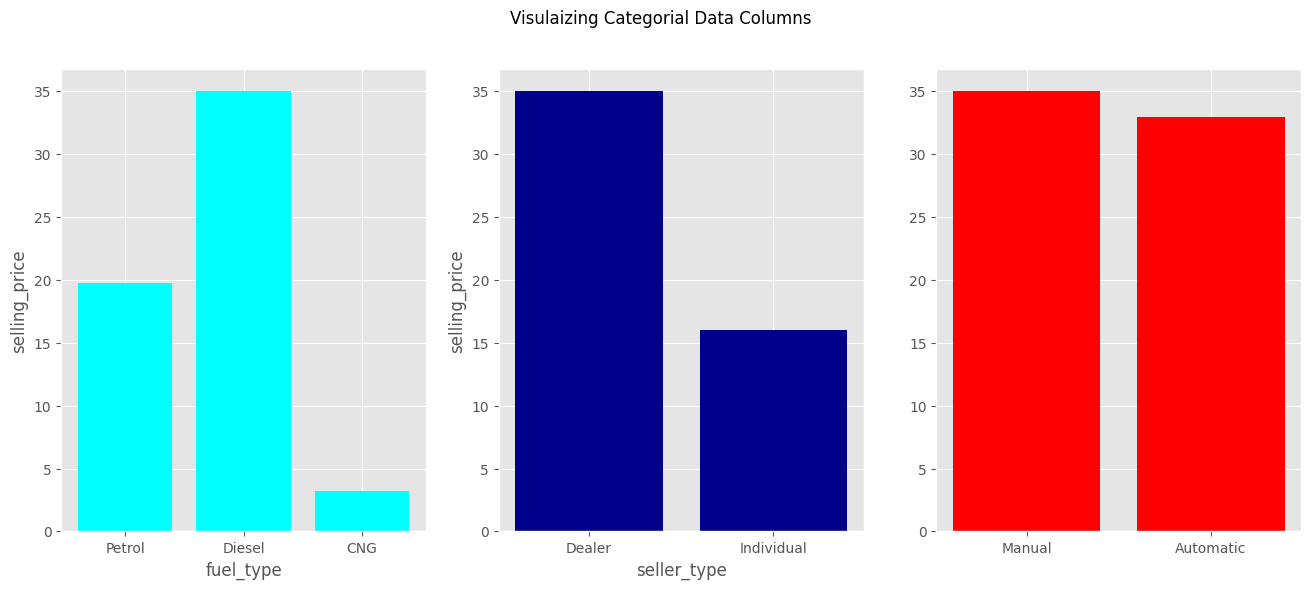

In [ ]:
style.use('ggplot')
fig=plt.figure(figsize=(16,6))
fig.suptitle("Visulaizing Categorial Data Columns")
plt.subplot(1,3,1)
plt.bar(fuel_type,selling_price,color='aqua')
plt.xlabel("fuel_type")
plt.ylabel("selling_price")
plt.subplot(1,3,2)
plt.bar(seller_type,selling_price,color='darkblue')
plt.xlabel("seller_type")
plt.ylabel("selling_price")
plt.subplot(1,3,3)
plt.bar(transmission,selling_price,color='red')

<Axes: xlabel='Transmission', ylabel='Selling_Price'>

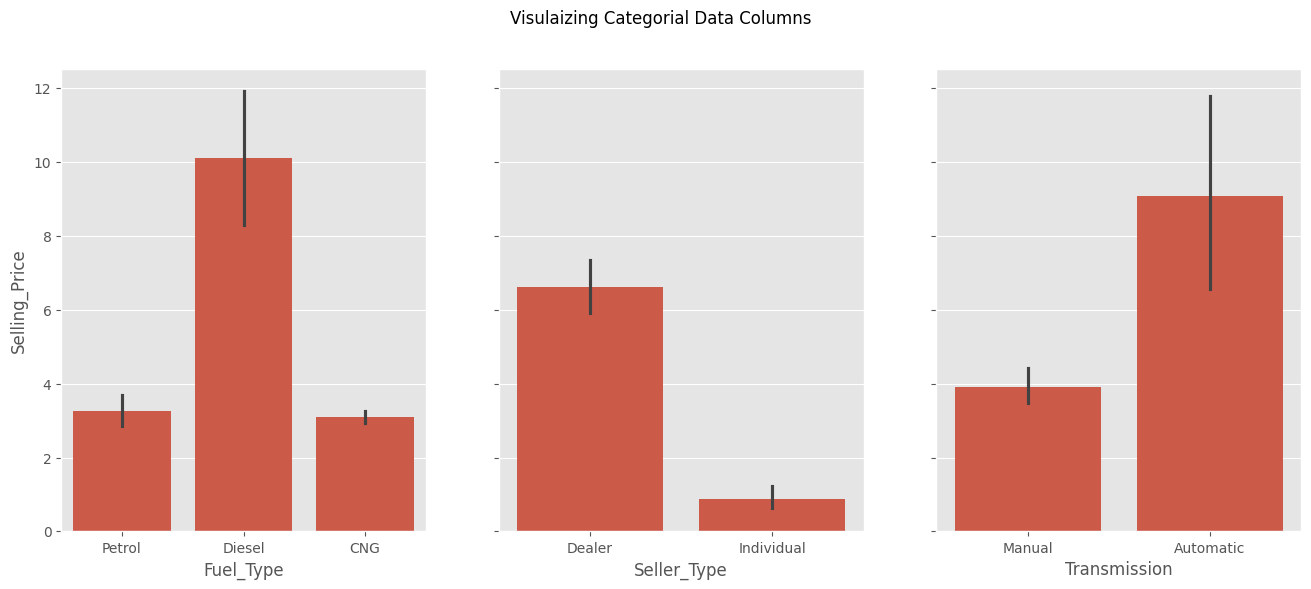

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(16,6),sharey=True)
fig.suptitle("Visulaizing Categorial Data Columns")
sns.barplot(x=fuel_type,y=selling_price,ax=axes[0])
sns.barplot(x=seller_type,y=selling_price,ax=axes[1])
sns.barplot(x=transmission,y=selling_price,ax=axes[2])

In [ ]:
petrol_data=df.groupby("Fuel_Type").get_group('Petrol')
petrol_data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,239.000000,239.000000,239.000000,239.000000,239.000000
mean,2013.539749,3.264184,5.583556,33528.937238,0.050209
std,3.042674,3.135537,5.290685,40308.984886,0.270368
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.600000,0.940000,13850.000000,0.000000
50%,2014.000000,2.650000,4.600000,25870.000000,0.000000
75%,2016.000000,5.200000,7.980000,44271.000000,0.000000
max,2017.000000,19.750000,23.730000,500000.000000,3.000000


In [ ]:
diesel_data=df.groupby("Fuel_Type").get_group('Diesel')
diesel_data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,58.000000,58.000000,58.000000,58.000000,58.000000
mean,2013.948276,10.102759,15.646034,50675.775862,0.017241
std,2.219708,7.103178,13.560739,30495.519576,0.131306
min,2005.000000,3.100000,5.700000,2071.000000,0.000000
25%,2013.000000,5.012500,8.897500,38250.000000,0.000000
50%,2014.000000,7.600000,10.380000,45000.000000,0.000000
75%,2015.000000,12.312500,15.790000,59750.000000,0.000000
max,2018.000000,35.000000,92.600000,197176.000000,1.000000


In [ ]:
cng_data=df.groupby("Fuel_Type").get_group('CNG')
cng_data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,2.000000,2.000000,2.000000,2.000000,2.0
mean,2013.000000,3.100000,6.415000,42749.000000,0.0
std,2.828427,0.212132,1.873833,10251.634114,0.0
min,2011.000000,2.950000,5.090000,35500.000000,0.0
25%,2012.000000,3.025000,5.752500,39124.500000,0.0
50%,2013.000000,3.100000,6.415000,42749.000000,0.0
75%,2014.000000,3.175000,7.077500,46373.500000,0.0
max,2015.000000,3.250000,7.740000,49998.000000,0.0


In [ ]:
df=df.drop(['Car_Name'],axis=1)

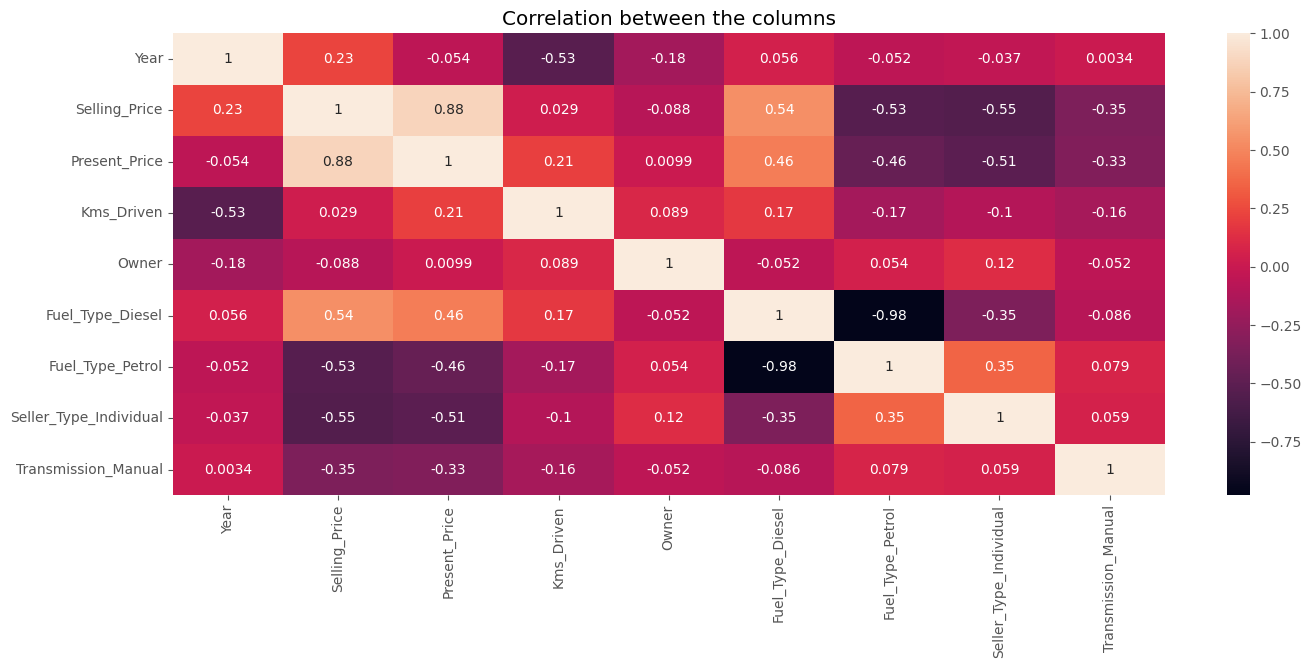

In [ ]:
plt.figure(figsize=(16,6))
df_encoded = df.copy()


df_encoded = pd.get_dummies(df_encoded, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

sns.heatmap(df_encoded.corr(), annot=True)
plt.title('Correlation between the columns')
plt.show()

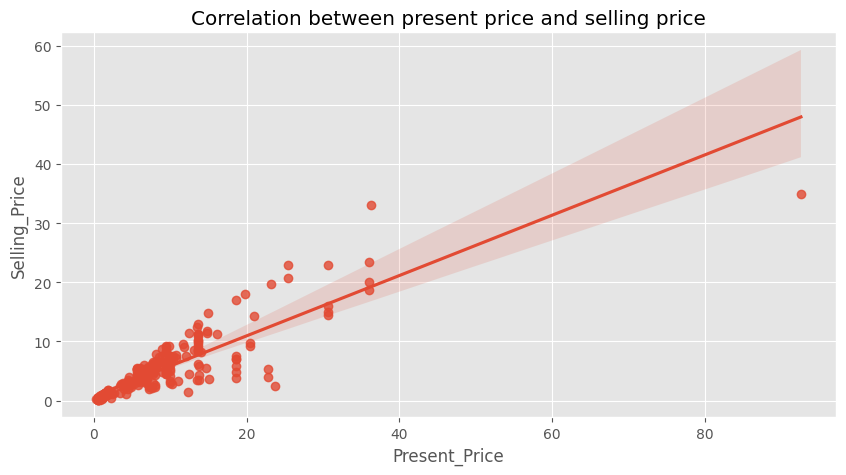

In [ ]:
fig = plt.figure(figsize=(10,5))
plt.title('Correlation between present price and selling price')
sns.regplot(x='Present_Price', y='Selling_Price', data=df)
plt.show()

In [ ]:
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']
print("Shape of X is:",X.shape)
print("Shape of y is:",y.shape)

Shape of X is: (299, 7)
Shape of y is: (299,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print("X_test Shape :", X_test.shape)
print("X_train Shape :", X_train.shape)
print("y_test Shape :", y_test.shape)
print("y_train Shape :", y_train.shape)

X_test Shape : (90, 7)
X_train Shape : (209, 7)
y_test Shape : (90,)
y_train Shape : (209,)


In [ ]:
# Concatenate X_train and X_test to apply one-hot encoding consistently
combined_X = pd.concat([X_train, X_test], ignore_index=True)

# Apply one-hot encoding to the combined dataset
combined_X_encoded = pd.get_dummies(combined_X, drop_first=True)

# Split the encoded dataset back into X_train_encoded and X_test_encoded
X_train_encoded = combined_X_encoded.iloc[:len(X_train)]
X_test_encoded = combined_X_encoded.iloc[len(X_train):]

# Initialize and apply StandardScaler to the numerically encoded data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_encoded)
X_test = scaler.transform(X_test_encoded)

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [ ]:
# CREASTE A MODEL
model=LinearRegression()
# FIT THE MODEL
model.fit(X_train,y_train)
# Predic using model
pred=model.predict(X_test)

In [ ]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred)))

MAE: 1.376895409342682
MSE: 5.186151887064534
RMSE: 2.2773124263184736


In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Fuel_Type',y='Selling_Price',data=df)
plt.title('Selling Price depends on Fuel Type')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['Fuel_Type'],bins=30,kde=True)
plt.title('Fuel Type Distribution')
plt.show()

NameError: name 'plt' is not defined